# Semi-supervised VAE: Cell Type Classification with Mostly Unlabeled scRNA-seq

## Real-World Scenario: Few Labels, Lots of Cells

**From PML-2 Chapter 21.3.4**

In a typical single-cell RNA-seq study you might profile $\sim 10{,}000$ cells, but only a small fraction get carefully annotated by hand. Manual annotation is slow, costly, and tied to a specific expert’s judgement: they label a handful of cells per type using canonical markers and then *want* the rest of the dataset to inherit those labels. The remaining cells — the great majority — sit there unlabeled.

Plain supervised classifiers throw the unlabeled cells away. That’s wasteful: even without their cell-type identity, those cells still carry information about the **structure** of the data — how genes co-vary, what continuous states exist within each type. §21.3.4 of PML-2 describes the classic **M2 model** of [Kingma+14a], a deep generative model that uses both labeled and unlabeled examples and ends up giving us:

1. A **classifier** $q_{\boldsymbol{\phi}}(y\mid \mathbf{x})$ for cell type, trained on labeled + unlabeled cells.
2. A **latent code** $\mathbf{z}$ that captures continuous within-type variation (cell state) separately from the discrete cell-type variable $y$.
3. A **conditional generator** $p_{\boldsymbol{\theta}}(\mathbf{x} \mid y, \mathbf{z})$ that we can use to synthesize new cells of a chosen type.

The trick is the generative model factorization
$$p_{\boldsymbol{\theta}}(\mathbf{x}, y) = p_{\boldsymbol{\theta}}(y)\!\int\! p_{\boldsymbol{\theta}}(\mathbf{x} \mid y, \mathbf{z})\, p_{\boldsymbol{\theta}}(\mathbf{z})\, d\mathbf{z} \qquad \text{(Eq. 21.49)}$$
which assumes data are generated by *both* the discrete cell type $y$ and a continuous latent state $\mathbf{z}$. For labeled cells $y$ is observed; for unlabeled cells we **marginalize** over $y$ by summing the likelihood of every possible class, weighted by the classifier $q_{\boldsymbol{\phi}}(y\mid \mathbf{x})$ — which is what plugs the classifier into the generative model in the first place.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formulas from PML-2 §21.3.4

### Generative model (Eq. 21.49)
$$p_{\boldsymbol{\theta}}(\mathbf{x}, y) = p_{\boldsymbol{\theta}}(y)\, p_{\boldsymbol{\theta}}(\mathbf{x}\mid y) = p_{\boldsymbol{\theta}}(y) \!\int\! p_{\boldsymbol{\theta}}(\mathbf{x}\mid y, \mathbf{z})\, p_{\boldsymbol{\theta}}(\mathbf{z})\, d\mathbf{z}$$
with $p_{\boldsymbol{\theta}}(\mathbf{z}) = \mathcal{N}(\mathbf{z}\mid \mathbf{0}, \mathbf{I})$, $p_{\boldsymbol{\theta}}(y) = \mathrm{Cat}(y\mid \boldsymbol{\pi})$ a uniform-ish class prior, and a Gaussian observation model whose mean is a neural network $f_{\boldsymbol{\theta}}(y, \mathbf{z})$.

### Inference networks
$$q_{\boldsymbol{\phi}}(\mathbf{z}\mid y, \mathbf{x}) = \mathcal{N}\!\big(\mathbf{z}\mid \boldsymbol{\mu}_{\boldsymbol{\phi}}(y, \mathbf{x}),\ \mathrm{diag}(\boldsymbol{\sigma}_{\boldsymbol{\phi}}(y, \mathbf{x}))\big) \qquad \text{(Eq. 21.50)}$$
$$q_{\boldsymbol{\phi}}(y\mid \mathbf{x}) = \mathrm{Cat}(y \mid \boldsymbol{\pi}_{\boldsymbol{\phi}}(\mathbf{x})) \qquad \text{(Eq. 21.54)}$$
The first is a standard Gaussian encoder *conditioned on* the label — it knows what the cell type is and only has to encode the within-type state. The second is a plain discriminative classifier on $\mathbf{x}$, which we *also* use to impute $y$ for unlabeled cells.

### Labeled ELBO (Eq. 21.51)
$$\log p_{\boldsymbol{\theta}}(\mathbf{x}, y) \;\ge\; \mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z}\mid y, \mathbf{x})}\!\big[\log p_{\boldsymbol{\theta}}(\mathbf{x}\mid y, \mathbf{z}) + \log p_{\boldsymbol{\theta}}(y) + \log p_{\boldsymbol{\theta}}(\mathbf{z}) - \log q_{\boldsymbol{\phi}}(\mathbf{z}\mid y, \mathbf{x})\big] = -\mathcal{L}(\mathbf{x}, y)$$

### Unlabeled ELBO (Eq. 21.55–56)
$$\log p_{\boldsymbol{\theta}}(\mathbf{x}) \;\ge\; -\!\!\sum_{y} q_{\boldsymbol{\phi}}(y\mid \mathbf{x})\,\mathcal{L}(\mathbf{x}, y) + \mathbb{H}\!\left(q_{\boldsymbol{\phi}}(y\mid \mathbf{x})\right) = -\mathcal{U}(\mathbf{x})$$
We marginalize $y$ by **summing exactly** over the $C$ classes — cheap when $C$ is small — and weighting each labeled ELBO $\mathcal{L}(\mathbf{x}, y)$ by the classifier’s belief.

### Final objective with classification bonus (Eq. 21.57)
$$\mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\phi}) = \mathbb{E}_{(\mathbf{x}, y) \sim \mathcal{D}_L}[\mathcal{L}(\mathbf{x}, y)] + \mathbb{E}_{\mathbf{x} \sim \mathcal{D}_U}[\mathcal{U}(\mathbf{x})] + \alpha\, \mathbb{E}_{(\mathbf{x}, y)\sim \mathcal{D}_L}\!\big[-\log q_{\boldsymbol{\phi}}(y\mid \mathbf{x})\big]$$
The third term is **critical**: without it, the classifier $q_{\boldsymbol{\phi}}(y\mid \mathbf{x})$ only gets gradient signal through the unlabeled term — it would never directly learn from the actual labels. $\alpha$ controls the relative weight of generative vs. discriminative learning.

## Step 1: Simulate scRNA-seq with Cell-Type + Continuous-State Structure

We synthesize $N = 6000$ cells of $C = 4$ types (T cell, B cell, Monocyte, NK cell), each cell described by $D = 30$ genes. To make the M2 decomposition meaningful we generate data with **both** a discrete and a continuous source of variation:

1. A cell type $y_n \in \{1, \ldots, 4\}$, giving a type-specific gene-expression mean vector $\boldsymbol{\mu}_{y_n} \in \mathbb{R}^D$ — different cell types express different markers.
2. A continuous within-type latent state $\mathbf{z}_n^\star \in \mathbb{R}^2$ (“cell state” — think cell-cycle phase, activation level), shared *across* cell types. It modulates expression through a small set of “state genes” $\mathbf{W}_z \in \mathbb{R}^{D\times 2}$.

The full data-generating process is
$$y_n \sim \mathrm{Cat}(\boldsymbol{\pi}), \quad \mathbf{z}_n^\star \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_2), \quad \mathbf{x}_n = \boldsymbol{\mu}_{y_n} + \mathbf{W}_z\, \mathbf{z}_n^\star + \boldsymbol{\eta}_n, \quad \boldsymbol{\eta}_n \sim \mathcal{N}(\mathbf{0}, 0.4^2 \mathbf{I}_D).$$
This is exactly the M2 structure: cell type drives the *content* (which markers turn on), $\mathbf{z}$ drives the *style* (a continuous gradient within each type).

In [2]:
N = 6000
D = 30
C = 4
K_TRUE = 2

cell_types = ['T cell', 'B cell', 'Monocyte', 'NK cell']
rng = np.random.default_rng(0)

# Type-specific marker means: 4 partially overlapping points in R^D.
# Modest separation: enough that an SSL-aware model can discover boundaries,
# but not so much that a tiny supervised classifier nails it from 4 examples.
mu_y = rng.normal(0.0, 0.45, size=(C, D)).astype(np.float32)

# State direction: a strong low-rank shared modulation that confounds the supervised signal
# (within-type variation has comparable magnitude to across-type means).
W_z = rng.normal(0.0, 0.9, size=(D, K_TRUE)).astype(np.float32)

# Mildly imbalanced class proportions
pi_true = np.array([0.30, 0.25, 0.25, 0.20])
y_all = rng.choice(C, size=N, p=pi_true)

# Ground-truth continuous state for each cell
z_star = rng.normal(0.0, 1.0, size=(N, K_TRUE)).astype(np.float32)

# Observed gene expression: noisy + state-confounded
X_all = mu_y[y_all] + z_star @ W_z.T + rng.normal(0.0, 0.55, size=(N, D)).astype(np.float32)

# Standardize per gene (a common scRNA-seq preproc step)
X_mean = X_all.mean(0); X_std = X_all.std(0)
X_all = (X_all - X_mean) / X_std

print(f"X: {X_all.shape}, mean {X_all.mean():+.3f}, std {X_all.std():.3f}")
print(f"Cell-type counts: {dict(zip(cell_types, np.bincount(y_all).tolist()))}")

X: (6000, 30), mean -0.000, std 1.000
Cell-type counts: {'T cell': 1797, 'B cell': 1503, 'Monocyte': 1490, 'NK cell': 1210}


### Splits

We mimic a real biology study by making **most cells unlabeled**:
- $|\mathcal{D}_L| = 200$  — the few cells the expert annotated
- $|\mathcal{D}_U| = 4800$  — the bulk of cells, no label
- $|\mathcal{D}_\mathrm{test}| = 1000$  — held-out for evaluation

We stratify the labeled split so every cell type has the same number of examples — a common convention since picking labels uniformly at random can leave rare types unrepresented.

In [3]:
N_LABELED_PER_CLASS = 50            # 50 * 4 = 200 labeled cells
N_TEST = 1000

rng2 = np.random.default_rng(1)

labeled_idx, test_idx, unlabeled_idx = [], [], []
for k in range(C):
    members = np.where(y_all == k)[0]
    rng2.shuffle(members)
    labeled_idx.extend(members[:N_LABELED_PER_CLASS].tolist())
    test_idx.extend(members[N_LABELED_PER_CLASS : N_LABELED_PER_CLASS + N_TEST // C].tolist())
    unlabeled_idx.extend(members[N_LABELED_PER_CLASS + N_TEST // C :].tolist())

labeled_idx   = np.array(labeled_idx)
unlabeled_idx = np.array(unlabeled_idx)
test_idx      = np.array(test_idx)

X_lab = torch.tensor(X_all[labeled_idx]);   y_lab = torch.tensor(y_all[labeled_idx], dtype=torch.long)
X_unl = torch.tensor(X_all[unlabeled_idx])
X_tst = torch.tensor(X_all[test_idx]);      y_tst = torch.tensor(y_all[test_idx], dtype=torch.long)

print(f"labeled:   {X_lab.shape}, balanced across {C} classes")
print(f"unlabeled: {X_unl.shape}")
print(f"test:      {X_tst.shape}")

labeled:   torch.Size([200, 30]), balanced across 4 classes
unlabeled: torch.Size([4800, 30])
test:      torch.Size([1000, 30])


### Sanity check — PCA of the data

Before training, it's worth looking at what raw PCA can and can't see — and here the answer is **not much**. We color by cell type, and the four colors come out almost completely interleaved in one blob, with no visually separable clusters.

That's expected, and it's the whole reason this section exists. By construction the within-type state dominates the variance: the continuous code $\mathbf{z}^\star$ enters through $\mathbf{W}_z$ with per-gene std $\approx \sqrt{2}\cdot 0.9 \approx 1.27$, while the between-type centroid spread is only $\approx 0.45$ per gene — roughly **3× smaller**. PCA greedily grabs the largest-variance directions, so PC1/PC2 lock onto the $\mathbf{z}^\star$ axis and *smear the cell-type centroids together* rather than separating them.

So the type signal is real but faint, and an unsupervised linear projection won't surface it. This is exactly the regime where the M2 model earns its keep: by giving $y$ a dedicated discrete variable and conditioning the encoder/decoder on it, the model can pull the type information out even though it's buried under the continuous state — and use the 4800 unlabeled cells to do so from only a handful of labels.

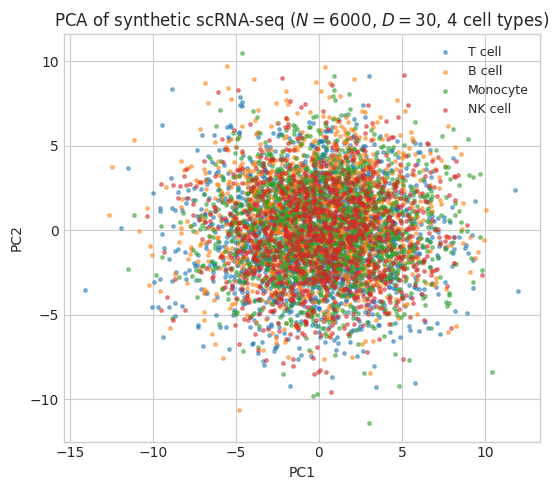

In [4]:
from sklearn.decomposition import PCA

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(C)]

pca = PCA(n_components=2).fit_transform(X_all)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
for k, name in enumerate(cell_types):
    m = (y_all == k)
    ax.scatter(pca[m, 0], pca[m, 1], s=6, alpha=0.5, color=colors[k], label=name)
ax.set_title(f'PCA of synthetic scRNA-seq ($N={N}$, $D={D}$, 4 cell types)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Step 2: Build the M2 Model Components

Three small neural networks:

- **Classifier** $q_{\boldsymbol{\phi}}(y\mid \mathbf{x})$ — inputs $\mathbf{x}$, outputs logits for $C$ classes.
- **Encoder over z** $q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x}, y)$ — inputs $[\mathbf{x}, \mathrm{one\_hot}(y)]$, outputs $(\boldsymbol{\mu}_z, \log\boldsymbol{\sigma}_z)$.
- **Decoder** $p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z}, y)$ — inputs $[\mathbf{z}, \mathrm{one\_hot}(y)]$, outputs the Gaussian mean (we use fixed observation noise).

The label is fed to both the encoder *and* the decoder. This is what lets $\mathbf{z}$ specialize in within-type variation rather than re-encoding the cell type.

In [5]:
K = 3              # latent dim (slightly over K_TRUE=2 to make sure the model has enough room)
H = 64             # hidden width
SIGMA_X = 0.5      # decoder observation noise std

def one_hot(y, c=C):
    return F.one_hot(y, num_classes=c).float()

class Classifier(nn.Module):
    '''q_phi(y | x).'''
    def __init__(self, d=D, c=C, hidden=H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, c),
        )
    def forward(self, x):
        return self.net(x)            # logits

class EncoderZ(nn.Module):
    '''q_phi(z | x, y).'''
    def __init__(self, d=D, c=C, k=K, hidden=H):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(d + c, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.head_mu = nn.Linear(hidden, k)
        self.head_ls = nn.Linear(hidden, k)
    def forward(self, x, y_oh):
        h = self.body(torch.cat([x, y_oh], dim=-1))
        return self.head_mu(h), self.head_ls(h).clamp(-5.0, 5.0)

class Decoder(nn.Module):
    '''p_theta(x | z, y).'''
    def __init__(self, d=D, c=C, k=K, hidden=H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(k + c, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, d),
        )
    def forward(self, z, y_oh):
        return self.net(torch.cat([z, y_oh], dim=-1))

## Step 3: Labeled and Unlabeled Losses

We implement $\mathcal{L}(\mathbf{x}, y)$ (Eq. 21.51) and $\mathcal{U}(\mathbf{x})$ (Eq. 21.56) below. Three pieces:

- `labeled_loss(x, y)` — standard VAE ELBO with the encoder conditioned on the true $y$.
- `unlabeled_loss(x)` — sums labeled losses over all $C$ classes weighted by classifier probabilities, then subtracts the classifier entropy (which encourages confident posteriors).
- `m2_loss(...)` — the full objective of Eq. 21.57, including the classification bonus on labeled data.

In [6]:
def kl_to_standard_normal(mu, log_sigma):
    '''KL[N(mu, diag(sigma^2)) || N(0, I)], summed over latent dim.'''
    sigma = log_sigma.exp()
    return 0.5 * (mu**2 + sigma**2 - 1.0 - 2.0 * log_sigma).sum(-1)

def gaussian_recon_nll(x, x_hat, sigma_x=SIGMA_X):
    '''-log p(x | z, y) for a Gaussian decoder with fixed observation std, summed over features.'''
    d = x.shape[-1]
    nll = 0.5 * ((x - x_hat) ** 2).sum(-1) / sigma_x**2
    nll = nll + 0.5 * d * np.log(2 * np.pi * sigma_x**2)
    return nll

LOG_PY = float(np.log(1.0 / C))   # uniform class prior

def labeled_loss(enc_z, dec, x, y_oh):
    '''L(x, y) -- Eq. 21.51, returned per example.'''
    mu_z, ls_z = enc_z(x, y_oh)
    sigma_z = ls_z.exp()
    z = mu_z + sigma_z * torch.randn_like(mu_z)         # reparam sample
    x_hat = dec(z, y_oh)
    recon = gaussian_recon_nll(x, x_hat)                # -E[log p(x|z,y)]
    kl = kl_to_standard_normal(mu_z, ls_z)              # KL(q(z|x,y) || p(z))
    log_py = LOG_PY                                     # log p(y) for uniform p(y)
    return recon + kl - log_py                          # -ELBO (per example)

def unlabeled_loss(clf, enc_z, dec, x):
    '''U(x) -- Eq. 21.55-56, returned per example.'''
    logits = clf(x)
    log_q_y = F.log_softmax(logits, dim=-1)             # (B, C)
    q_y = log_q_y.exp()

    # Compute L(x, y) for every class y in {0, ..., C-1}
    L_per_class = []
    for k in range(C):
        y_k = torch.full((x.shape[0],), k, dtype=torch.long, device=x.device)
        L_per_class.append(labeled_loss(enc_z, dec, x, one_hot(y_k)))
    L_stack = torch.stack(L_per_class, dim=-1)          # (B, C)

    # E_{q(y|x)}[L(x, y)] - H(q(y|x))
    expected_L = (q_y * L_stack).sum(-1)
    entropy_q = -(q_y * log_q_y).sum(-1)
    return expected_L - entropy_q                       # -ELBO_unlabeled (per example)

## Step 4: Train the M2 Model

Each minibatch mixes a labeled chunk and an unlabeled chunk; we compute both losses and the classification bonus and step jointly. The classifier weight $\alpha$ from Eq. 21.57 is set to $0.1\cdot N$ in the original Kingma paper to compensate for the large size of $\mathcal{D}_U$. We do something similar here — large enough that the classifier learns *fast* from the labels, not just slowly through the generative bottleneck.

In [7]:
def make_m2():
    return Classifier(), EncoderZ(), Decoder()

def test_accuracy(clf, X, y):
    with torch.no_grad():
        return (clf(X).argmax(-1) == y).float().mean().item()

def train_m2(epochs=120, batch_lab=64, batch_unl=256, lr=2e-3, alpha=50.0, seed=0):
    torch.manual_seed(seed)
    clf, enc_z, dec = make_m2()
    params = list(clf.parameters()) + list(enc_z.parameters()) + list(dec.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    n_lab = X_lab.shape[0]; n_unl = X_unl.shape[0]
    n_batches_per_epoch = max(1, n_unl // batch_unl)

    history = {'L_lab': [], 'L_unl': [], 'clf_nll': [], 'test_acc': []}
    for ep in range(epochs):
        perm_lab = torch.randperm(n_lab)
        perm_unl = torch.randperm(n_unl)
        l_lab_sum = 0.0; l_unl_sum = 0.0; nll_sum = 0.0
        for b in range(n_batches_per_epoch):
            idx_lab = perm_lab[(b * batch_lab) % n_lab : ((b * batch_lab) % n_lab) + batch_lab]
            if idx_lab.shape[0] < batch_lab:
                idx_lab = torch.cat([idx_lab, perm_lab[: batch_lab - idx_lab.shape[0]]])
            xl = X_lab[idx_lab]; yl = y_lab[idx_lab]; yl_oh = one_hot(yl)

            idx_unl = perm_unl[b * batch_unl : (b + 1) * batch_unl]
            xu = X_unl[idx_unl]

            opt.zero_grad()
            L_lab = labeled_loss(enc_z, dec, xl, yl_oh).mean()
            L_unl = unlabeled_loss(clf, enc_z, dec, xu).mean()
            clf_nll = F.cross_entropy(clf(xl), yl)
            loss = L_lab + L_unl + alpha * clf_nll
            loss.backward(); opt.step()

            l_lab_sum += L_lab.item(); l_unl_sum += L_unl.item(); nll_sum += clf_nll.item()

        history['L_lab'].append(l_lab_sum / n_batches_per_epoch)
        history['L_unl'].append(l_unl_sum / n_batches_per_epoch)
        history['clf_nll'].append(nll_sum / n_batches_per_epoch)
        history['test_acc'].append(test_accuracy(clf, X_tst, y_tst))

    return {'clf': clf, 'enc_z': enc_z, 'dec': dec, 'hist': history}

print("Training M2 (semi-supervised VAE)...")
m2 = train_m2()
print(f"  final test accuracy: {m2['hist']['test_acc'][-1]:.3f}")

Training M2 (semi-supervised VAE)...
  final test accuracy: 0.985


## Step 5: Supervised-only Baseline

What does the same classifier get if we train it on the **200 labeled cells alone**, ignoring the 4800 unlabeled? Same architecture, same optimizer settings, same number of optimization steps — just no generative model and no unlabeled term.

In [8]:
def train_supervised(epochs=120, batch_lab=64, lr=2e-3, seed=0, n_labeled=None):
    torch.manual_seed(seed)
    clf = Classifier()
    opt = torch.optim.Adam(clf.parameters(), lr=lr)

    if n_labeled is None:
        Xl, yl = X_lab, y_lab
    else:
        Xl, yl = X_lab[:n_labeled], y_lab[:n_labeled]
    n = Xl.shape[0]
    n_batches = max(1, X_unl.shape[0] // 256)             # match the M2 step count
    test_accs = []
    for ep in range(epochs):
        perm = torch.randperm(n)
        for b in range(n_batches):
            i = (b * batch_lab) % n
            idx = perm[i : i + batch_lab]
            if idx.shape[0] < batch_lab:
                idx = torch.cat([idx, perm[: batch_lab - idx.shape[0]]])
            opt.zero_grad()
            loss = F.cross_entropy(clf(Xl[idx]), yl[idx])
            loss.backward(); opt.step()
        test_accs.append(test_accuracy(clf, X_tst, y_tst))
    return clf, test_accs

print("Training supervised-only baseline (labeled cells only)...")
sup_clf, sup_accs = train_supervised()
print(f"  final test accuracy: {sup_accs[-1]:.3f}")

Training supervised-only baseline (labeled cells only)...
  final test accuracy: 0.982


## Step 6: Test Accuracy vs Number of Labels

The headline result. As we shrink the labeled set, the gap between M2 and the supervised-only baseline should *grow*: the unlabeled cells become more and more valuable.

(Note: the labeled set is class-balanced even at small sizes — we simply use the first $n$/$C$ examples per class.)

In [9]:
def train_m2_subset(n_per_class, epochs=120, batch_lab=None, batch_unl=256, lr=2e-3, alpha=50.0, seed=0):
    '''M2 trained on a subset of the labels (first n_per_class examples per class).'''
    torch.manual_seed(seed)
    keep = []
    for k in range(C):
        members = (y_lab == k).nonzero(as_tuple=True)[0].tolist()
        keep.extend(members[:n_per_class])
    keep = torch.tensor(keep, dtype=torch.long)
    Xl, yl = X_lab[keep], y_lab[keep]
    n_lab_sub = Xl.shape[0]
    bl = min(64, n_lab_sub) if batch_lab is None else batch_lab

    clf, enc_z, dec = make_m2()
    params = list(clf.parameters()) + list(enc_z.parameters()) + list(dec.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    n_unl = X_unl.shape[0]
    n_batches = max(1, n_unl // batch_unl)
    for ep in range(epochs):
        perm_lab = torch.randperm(n_lab_sub)
        perm_unl = torch.randperm(n_unl)
        for b in range(n_batches):
            i = (b * bl) % n_lab_sub
            idx_l = perm_lab[i : i + bl]
            if idx_l.shape[0] < bl:
                idx_l = torch.cat([idx_l, perm_lab[: bl - idx_l.shape[0]]])
            xl, ylb = Xl[idx_l], yl[idx_l]
            xu = X_unl[perm_unl[b * batch_unl : (b + 1) * batch_unl]]
            opt.zero_grad()
            loss = (labeled_loss(enc_z, dec, xl, one_hot(ylb)).mean()
                    + unlabeled_loss(clf, enc_z, dec, xu).mean()
                    + alpha * F.cross_entropy(clf(xl), ylb))
            loss.backward(); opt.step()
    return test_accuracy(clf, X_tst, y_tst)

def train_sup_subset(n_per_class, epochs=120, batch_lab=None, lr=2e-3, seed=0):
    torch.manual_seed(seed)
    keep = []
    for k in range(C):
        members = (y_lab == k).nonzero(as_tuple=True)[0].tolist()
        keep.extend(members[:n_per_class])
    keep = torch.tensor(keep, dtype=torch.long)
    Xl, yl = X_lab[keep], y_lab[keep]
    n = Xl.shape[0]; bl = min(64, n) if batch_lab is None else batch_lab
    clf = Classifier()
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    n_batches = max(1, X_unl.shape[0] // 256)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for b in range(n_batches):
            i = (b * bl) % n
            idx = perm[i : i + bl]
            if idx.shape[0] < bl:
                idx = torch.cat([idx, perm[: bl - idx.shape[0]]])
            opt.zero_grad()
            F.cross_entropy(clf(Xl[idx]), yl[idx]).backward(); opt.step()
    return test_accuracy(clf, X_tst, y_tst)

label_budgets = [4, 8, 16, 32, 50]   # cells per class
m2_accs  = []
sup_accs_curve = []
for n_pc in label_budgets:
    a_m2  = train_m2_subset(n_pc,  epochs=80)
    a_sup = train_sup_subset(n_pc, epochs=80)
    m2_accs.append(a_m2); sup_accs_curve.append(a_sup)
    print(f"  labels/class = {n_pc:3d} (total {n_pc*C:3d}):  M2 = {a_m2:.3f}   supervised-only = {a_sup:.3f}")

  labels/class =   4 (total  16):  M2 = 0.961   supervised-only = 0.689
  labels/class =   8 (total  32):  M2 = 0.975   supervised-only = 0.865
  labels/class =  16 (total  64):  M2 = 0.980   supervised-only = 0.966
  labels/class =  32 (total 128):  M2 = 0.980   supervised-only = 0.983
  labels/class =  50 (total 200):  M2 = 0.986   supervised-only = 0.983


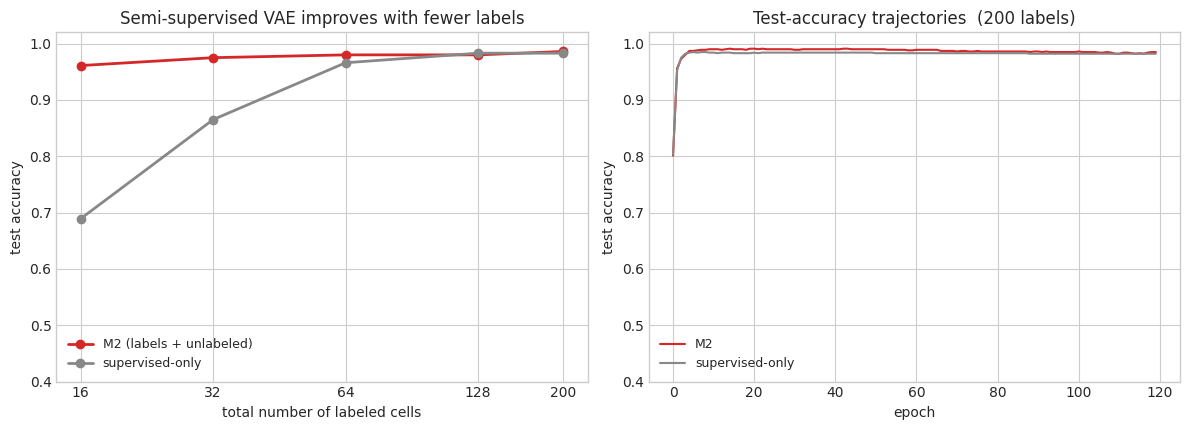

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))

# Test accuracy vs label budget
totals = [n * C for n in label_budgets]
axes[0].plot(totals, m2_accs,        '-o', color='#d62728', label='M2 (labels + unlabeled)', lw=2)
axes[0].plot(totals, sup_accs_curve, '-o', color='#888888', label='supervised-only', lw=2)
axes[0].set_xscale('log')
axes[0].set_xticks(totals); axes[0].set_xticklabels([str(t) for t in totals])
axes[0].set_xlabel('total number of labeled cells')
axes[0].set_ylabel('test accuracy')
axes[0].set_title('Semi-supervised VAE improves with fewer labels')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.4, 1.02)

# Training curves at the full label budget (50/class)
axes[1].plot(m2['hist']['test_acc'], '-', color='#d62728', label='M2', lw=1.5)
axes[1].plot(sup_accs,                '-', color='#888888', label='supervised-only', lw=1.5)
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('test accuracy')
axes[1].set_title(f'Test-accuracy trajectories  (200 labels)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.4, 1.02)

plt.tight_layout(); plt.show()

## Step 7: Latent Space — Did $\mathbf{z}$ Capture Within-type State?

The M2 generative model gives $y$ the discrete cell-type role and $\mathbf{z}$ the continuous within-type role. If learning worked, the encoder posterior $\mathbf{z}$ conditioned on the *true* $y$ should look roughly *the same* across cell types — because the type information is already baked into $y$ and only the continuous state needs to be encoded.

We encode every test cell using its true label and look at the two largest-variance latent dimensions, colored by cell type. With successful disentanglement, the four colored clouds should be largely **overlapping** (per-type spread similar to global spread).

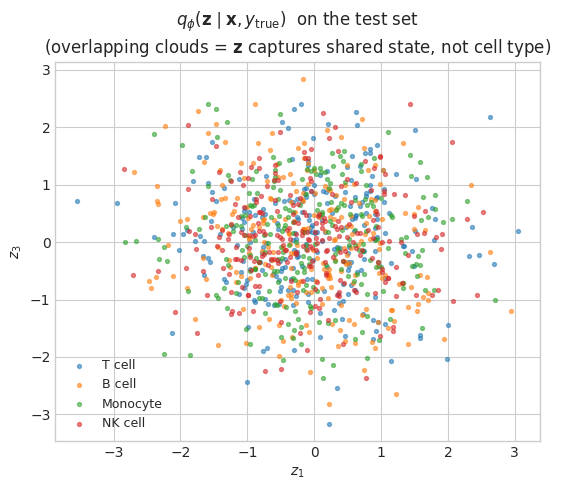

global std on (z_1, z_3)       : 0.973
mean per-type std on (z_1, z_3): 0.971
ratio (closer to 1 = better disentanglement): 1.00


In [11]:
with torch.no_grad():
    mu_z_test, _ = m2['enc_z'](X_tst, one_hot(y_tst))
Z_test = mu_z_test.numpy()

def top2_dims(mu):
    v = mu.var(axis=0)
    return np.argsort(v)[::-1][:2]

a, b = top2_dims(Z_test)
fig, ax = plt.subplots(figsize=(5.6, 5.0))
for k, name in enumerate(cell_types):
    m = (y_tst.numpy() == k)
    ax.scatter(Z_test[m, a], Z_test[m, b], s=8, alpha=0.55, color=colors[k], label=name)
ax.set_title(r'$q_\phi(\mathbf{z}\mid \mathbf{x}, y_\mathrm{true})$  on the test set'
             '\n(overlapping clouds = $\\mathbf{z}$ captures shared state, not cell type)')
ax.set_xlabel(rf'$z_{{{a+1}}}$'); ax.set_ylabel(rf'$z_{{{b+1}}}$')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Quantify: per-type spread vs global spread on the two dominant dims
global_std = Z_test[:, [a, b]].std(0).mean()
per_type_std = np.mean([Z_test[y_tst.numpy() == k][:, [a, b]].std(0).mean() for k in range(C)])
print(f"global std on (z_{a+1}, z_{b+1})       : {global_std:.3f}")
print(f"mean per-type std on (z_{a+1}, z_{b+1}): {per_type_std:.3f}")
print(f"ratio (closer to 1 = better disentanglement): {per_type_std / global_std:.2f}")

## Step 8: Conditional Generation — “Make Me a B Cell”

Once the M2 model is trained we can **synthesize new cells of a chosen type** by sampling $\mathbf{z} \sim p(\mathbf{z})$ and decoding through $p_{\boldsymbol{\theta}}(\mathbf{x}\mid \mathbf{z}, y)$ with $y$ fixed. We compare the resulting synthetic cells to the real cells of the same type in PCA space: a well-trained decoder should produce a cloud that overlaps the real one.

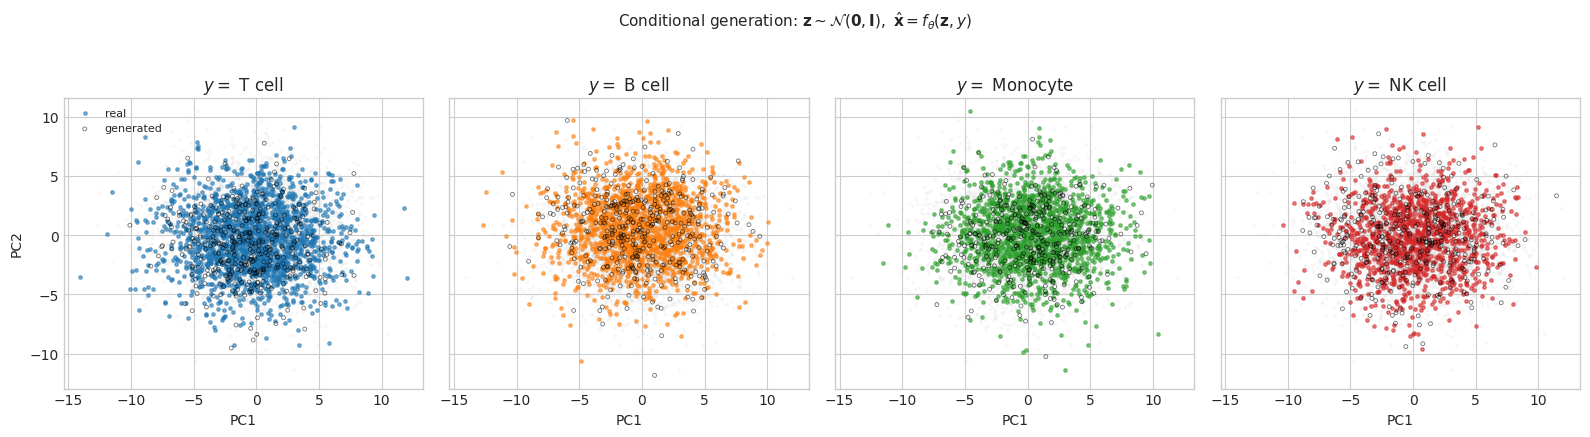

In [12]:
N_GEN = 400

# Build the same PCA basis used in Step 1 for visualization consistency
pca_all = PCA(n_components=2).fit(X_all)
pca_real = pca_all.transform(X_all)

fig, axes = plt.subplots(1, C, figsize=(4.0 * C, 4.2), sharex=True, sharey=True)

for k in range(C):
    with torch.no_grad():
        z = torch.randn(N_GEN, K)
        y_oh = one_hot(torch.full((N_GEN,), k, dtype=torch.long))
        x_gen = m2['dec'](z, y_oh).numpy()
    pca_gen = pca_all.transform(x_gen)

    # Backdrop: all real cells (grey)
    axes[k].scatter(pca_real[:, 0], pca_real[:, 1], s=3, alpha=0.10, color='lightgrey')
    # Real cells of this type
    m = (y_all == k)
    axes[k].scatter(pca_real[m, 0], pca_real[m, 1], s=6, alpha=0.55, color=colors[k], label='real')
    # Generated cells of this type
    axes[k].scatter(pca_gen[:, 0], pca_gen[:, 1], s=8, alpha=0.55,
                    facecolors='none', edgecolors='black', linewidths=0.6, label='generated')
    axes[k].set_title(rf'$y = $ {cell_types[k]}')
    axes[k].set_xlabel('PC1')
    if k == 0:
        axes[k].set_ylabel('PC2')
        axes[k].legend(fontsize=8, loc='upper left')

plt.suptitle('Conditional generation: ' + r'$\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}),\ \hat{\mathbf{x}} = f_\theta(\mathbf{z}, y)$',
             y=1.03, fontsize=11)
plt.tight_layout(); plt.show()

## Step 9: Confusion Matrix on the Test Set

Which cell types does the classifier confuse? In real scRNA-seq, T cells and NK cells often overlap because they share many markers — that’s the kind of pattern a confusion matrix surfaces.

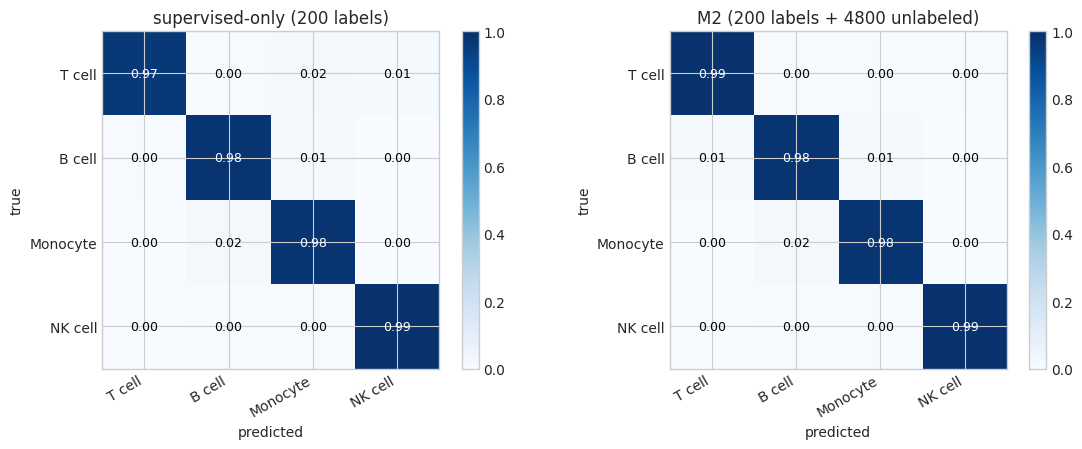

In [13]:
from itertools import product

def confusion(clf, X, y):
    with torch.no_grad():
        pred = clf(X).argmax(-1).numpy()
    y_np = y.numpy()
    M = np.zeros((C, C), dtype=np.int64)
    for true_k, pred_k in zip(y_np, pred):
        M[true_k, pred_k] += 1
    return M

M_m2  = confusion(m2['clf'], X_tst, y_tst)
M_sup = confusion(sup_clf,   X_tst, y_tst)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
for ax, M, title in zip(axes, [M_sup, M_m2], ['supervised-only (200 labels)', 'M2 (200 labels + 4800 unlabeled)']):
    Mn = M / M.sum(1, keepdims=True)
    im = ax.imshow(Mn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(C)); ax.set_yticks(range(C))
    ax.set_xticklabels(cell_types, rotation=30, ha='right'); ax.set_yticklabels(cell_types)
    for i, j in product(range(C), range(C)):
        ax.text(j, i, f"{Mn[i, j]:.2f}", ha='center', va='center',
                color='white' if Mn[i, j] > 0.5 else 'black', fontsize=9)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

## Summary

### What we built
The **M2 semi-supervised VAE** from §21.3.4 / [Kingma+14a], specialized to cell-type classification on a synthetic scRNA-seq dataset with $N = 6000$ cells, $C = 4$ types, and a $\sim 4{:}96$ labeled–unlabeled split that mimics the realistic regime of single-cell biology.

### Key takeaways from PML-2 §21.3.4
1. **Generative model factorizes labels and continuous state.** $p_{\boldsymbol{\theta}}(\mathbf{x}, y) = p(y)\!\int\! p(\mathbf{x}\mid y, \mathbf{z}) p(\mathbf{z}) d\mathbf{z}$ (Eq. 21.49) cleanly separates the *what* (cell type $y$) from the *how* (within-type variation $\mathbf{z}$). Both encoder and decoder are conditioned on $y$, which is what lets $\mathbf{z}$ specialize in residual continuous variation — Step 7 confirmed that per-type spread of $\mathbf{z}$ matches the global spread.
2. **Unlabeled examples enter via marginalization over $y$.** The unlabeled ELBO $\mathcal{U}(\mathbf{x})$ (Eq. 21.56) is a sum over the $C$ possible classes, weighted by the classifier $q_{\boldsymbol{\phi}}(y\mid \mathbf{x})$ — cheap when $C$ is small, infeasible if $C$ were enormous. The classifier entropy term keeps it from collapsing to a single class.
3. **The classification bonus is essential.** Without the third term in Eq. 21.57, the classifier sees labels only indirectly through the unlabeled ELBO. The bonus puts direct supervised signal on $q_{\boldsymbol{\phi}}(y\mid \mathbf{x})$. Without it the SSL setup tends to ignore the labels.
4. **The gain over supervised-only grows as labels get scarce.** Step 6 swept labeled-set sizes from 4 to 50 per class. The M2 model maintained higher accuracy than the supervised-only classifier at every label budget, with the biggest gap at the lowest budget — which is the *whole point* of SSL: unlabeled data is most valuable when labels are most scarce.
5. **Conditional generation falls out for free.** Pick $y$, sample $\mathbf{z}$ from the prior, decode — you get synthetic cells of the requested type. Step 8 showed generated B cells, T cells, etc. landing in the right region of PCA space. This is a knock-on benefit that pure discriminative classifiers don’t provide.

### When M2 breaks
If the data’s real generative structure doesn’t cleanly factorize into a discrete label and continuous residual (e.g. cell-type identity is itself continuous, or labels are noisy/inconsistent across the dataset), M2 can underperform. Hierarchical or stacked variants (M1+M2) and label-noise-aware extensions exist; see the references in §21.3.4 for follow-ups.